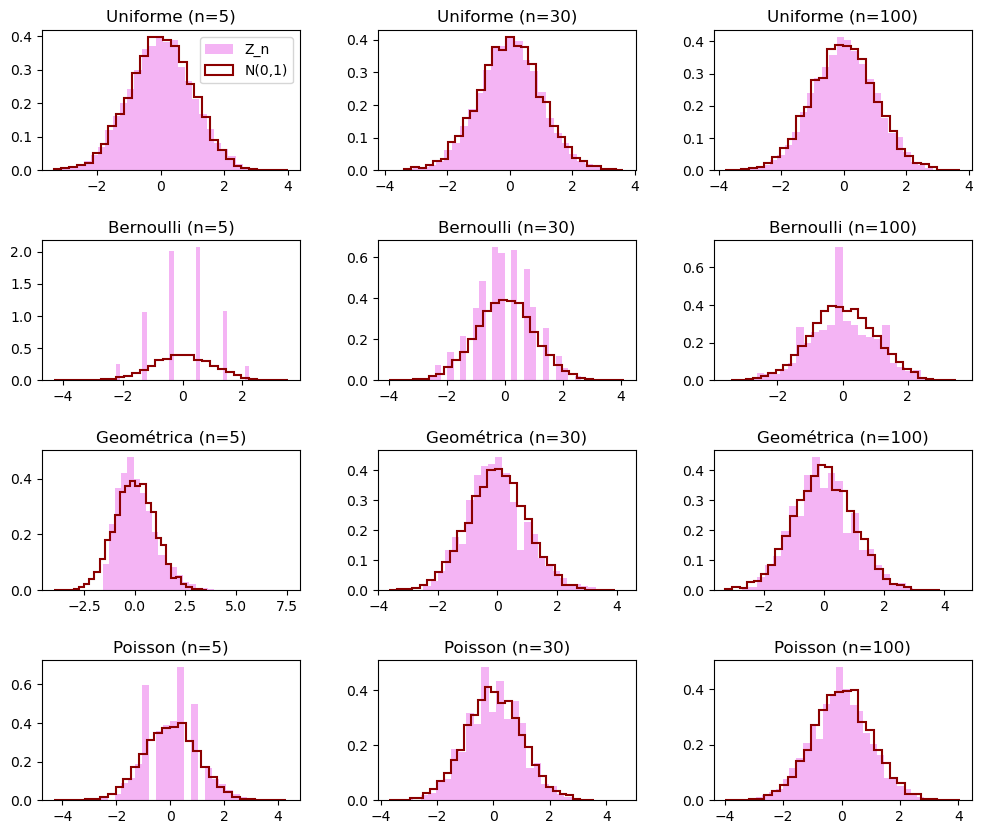

In [6]:
# Exercicio 1

import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
M = 5000  
valores_n = [5, 30, 100]
dists = ["Uniforme", "Bernoulli", "Geométrica", "Poisson"]

fig, axes = plt.subplots(len(dists), len(valores_n), figsize=(12, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i, nome_dist in enumerate(dists):
    for j, n in enumerate(valores_n):
        
        # Gerando a matriz de amostras e definindo os valores teóricos associados
        if nome_dist == "Uniforme":
            amostras = np.random.uniform(0, 1, size=(M, n))
            mu = 0.5
            sigma = np.sqrt(1/12)
            
        elif nome_dist == "Bernoulli":
            amostras = np.random.binomial(1, 0.5, size=(M, n))
            mu = 0.5
            sigma = 0.5
            
        elif nome_dist == "Geométrica":
            amostras = np.random.geometric(0.5, size=(M, n))
            mu = 2.0
            sigma = np.sqrt(2.0)
            
        elif nome_dist == "Poisson":
            amostras = np.random.poisson(3.0, size=(M, n))
            mu = 3.0
            sigma = np.sqrt(3.0)
            
        # Aplicação direta do TCL
        x_barra = np.mean(amostras, axis=1)
        Zn = np.sqrt(n) * (x_barra - mu) / sigma
        
        grafico = axes[i, j]
        grafico.hist(Zn, bins=30, density=True, alpha=0.6, color='violet', label='Z_n')
        
        # Sobreposição com a N(0,1) para a comparação
        normal_padrao = np.random.normal(0, 1, size=M)
        grafico.hist(normal_padrao, bins=30, density=True, color='darkred', histtype='step', lw=1.5, label='N(0,1)')
        
        grafico.set_title(f"{nome_dist} (n={n})")
        
        # Legenda no gráfico
        if i == 0 and j == 0:
            grafico.legend(loc='upper right')

plt.show()

In [ ]:
Analise dos resultados obtidos:

1. À medida que o n cresce, a distribuição de Z_n fica cada vez mais parecida com a Normal(0,1).

2. A Uniforme e a Bernoulli convergem muito mais rápido. 


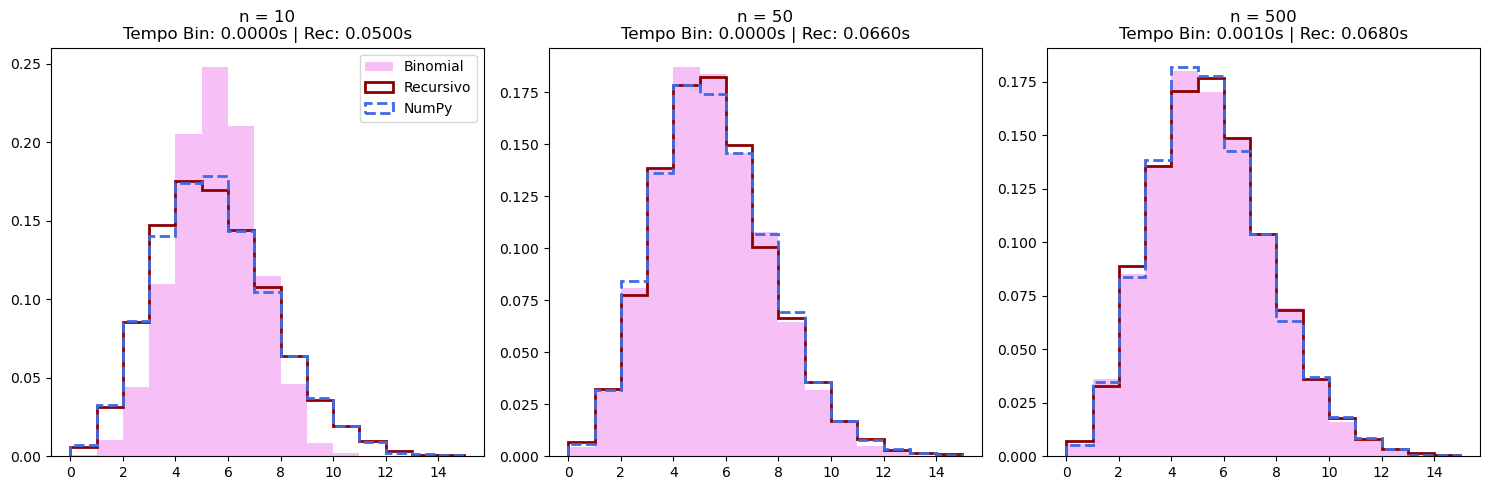

In [13]:
# Exercicio 2

import numpy as np
import matplotlib.pyplot as plt
import time

# Parâmetros
lambd = 5.0
M = 10000
valores_n = [10, 50, 500]

# Método recursivo
def poisson_recursivo(lambd, M):
    amostras = []
    for i in range(M):
        u = np.random.uniform(0, 1)
        k = 0
        p = np.exp(-lambd)
        F = p
        
        while u > F:
            k = k + 1
            p = (lambd / k) * p
            F = F + p
            
        amostras.append(k)
        
    return amostras

# Prepara a figura para colocar os 3 gráficos lado a lado
plt.figure(figsize=(15, 5))
posicao_grafico = 1

for n in valores_n:
    p_n = lambd / n

    # Marcando o tempo nos métodos:
    
    # Método Binomial
    inicio_bin = time.time()
    amostra_binomial = np.random.binomial(n, p_n, M)
    tempo_bin = time.time() - inicio_bin
    
    # Método Recursivo
    inicio_rec = time.time()
    amostra_recursiva = poisson_recursivo(lambd, M)
    tempo_rec = time.time() - inicio_rec
    
    # Método do NumPy
    amostra_numpy = np.random.poisson(lambd, M)
    
    # Desenhar o gráfico na posição correta
    plt.subplot(1, 3, posicao_grafico)
    
    # Usando bins de 0 a 15 porque a média é 5
    plt.hist(amostra_binomial, bins=15, range=(0, 15), density=True, alpha=0.5, color='violet', label='Binomial')
    plt.hist(amostra_recursiva, bins=15, range=(0, 15), density=True, histtype='step', color='darkred', lw=2, label='Recursivo')
    plt.hist(amostra_numpy, bins=15, range=(0, 15), density=True, histtype='step', color='royalblue', lw=2, linestyle='--', label='NumPy')
    
    plt.title(f"n = {n}\nTempo Bin: {tempo_bin:.4f}s | Rec: {tempo_rec:.4f}s")
    
    # Colocar a legenda só no primeiro para ficar limpo
    if posicao_grafico == 1:
        plt.legend(loc='upper right')
        
    posicao_grafico = posicao_grafico + 1

plt.tight_layout()
plt.show()

In [ ]:
Resultados obtidos:

Podemos perceber que quando n é pequeno, o histograma da Binomial se distancia bastante das linhas da Poisson, mas a medida que n aumenta, é 
a aproximação fica muito boa e as distribuições geram histogramas com o mesmo formato.
Em relaçao ao tempo de execuação, percebemos que a aproximação Binomial usando o NumPy é bem rápida do que quando utilizamos o método Recursivo 
por causa do loop criado.
Vantagens e desvantagens:
Binomial: É muito rápida, mas matematicamente não é uma Poisson exata, precisando de um n alto para não dar erro.
Recursivo: Gera a distribuição exata sem depender de funções prontas mas é computacionalmente muito lento.